# Eixo 6 — Impacto na Qualidade de Vida

**Base:** Behavioral Risk Factor Surveillance System (BRFSS), 2015  
**Pergunta:** quantos dias por mês pessoas com diabetes e/ou hipertensão relatam saúde física ou mental ruim, e como avaliam sua saúde geral?

Este notebook faz parte do projeto `eda-diabetes` e contém apenas a análise do Eixo 6. Os resultados são associações transversais e autorrelatadas; não demonstram causalidade.

## Preparação e verificação dos dados

O notebook localiza automaticamente o CSV na pasta `dataset` da raiz do projeto, mesmo quando a execução é iniciada dentro da subpasta da análise.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    pass  # O executor de validação injeta uma função display equivalente.

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titlesize": 14, "axes.labelsize": 11})

nome_dataset = "diabetes_binary_health_indicators_BRFSS2015.csv"
candidatos = [Path(nome_dataset), Path("dataset") / nome_dataset, Path("../../dataset") / nome_dataset]
candidatos += [p / "dataset" / nome_dataset for p in [Path.cwd(), *Path.cwd().parents]]
DATA_PATH = next((p.resolve() for p in candidatos if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Dataset não encontrado. Mantenha a pasta dataset na raiz do projeto.")

df = pd.read_csv(DATA_PATH)
variaveis = [
    "Diabetes_binary", "HighBP", "Smoker", "HvyAlcoholConsump",
    "PhysHlth", "MentHlth", "GenHlth", "DiffWalk"
]
ausentes = [v for v in variaveis if v not in df.columns]
if ausentes:
    raise ValueError(f"Variáveis ausentes no dataset: {ausentes}")

resumo_base = pd.DataFrame({
    "Indicador": ["Linhas", "Colunas", "Valores ausentes nas variáveis usadas", "Linhas duplicadas completas"],
    "Valor": [len(df), df.shape[1], int(df[variaveis].isna().sum().sum()), int(df.duplicated().sum())]
})
display(resumo_base)
display(df[variaveis].describe().T.round(2))

,Indicador,Valor
0,Linhas,253680
1,Colunas,22
2,Valores ausentes nas variáveis usadas,0
3,Linhas duplicadas completas,24206


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.14,0.35,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.43,0.49,0.0,0.0,0.0,1.0,1.0
Smoker,253680.0,0.44,0.50,0.0,0.0,0.0,1.0,1.0
HvyAlcoholConsump,253680.0,0.06,0.23,0.0,0.0,0.0,0.0,1.0
PhysHlth,253680.0,4.24,8.72,0.0,0.0,0.0,3.0,30.0
MentHlth,253680.0,3.18,7.41,0.0,0.0,0.0,2.0,30.0
GenHlth,253680.0,2.51,1.07,1.0,2.0,2.0,3.0,5.0
DiffWalk,253680.0,0.17,0.37,0.0,0.0,0.0,0.0,1.0


A ausência de valores nulos nas variáveis selecionadas dispensa imputação. Registros idênticos são mantidos: em uma pesquisa populacional, respostas iguais não significam necessariamente duplicação da mesma pessoa, pois o arquivo não contém identificador individual.

# Eixo 6 — Impacto na Qualidade de Vida

**Pergunta:** quantos dias por mês pessoas com diabetes e/ou hipertensão relatam saúde física ou mental ruim, e como avaliam sua saúde geral?

Criamos quatro perfis mutuamente exclusivos: nenhum diagnóstico, só diabetes, só hipertensão e ambos. Como `PhysHlth` e `MentHlth` têm muitos zeros e forte assimetria, apresentamos média e mediana e usamos Kruskal–Wallis, um teste não paramétrico. Também calculamos a proporção com **14 ou mais dias ruins**, um resumo útil de carga frequente.

In [2]:
ordem_perfis = ["Nenhum", "Só diabetes", "Só hipertensão", "Ambos"]
condicoes = [
    (df["Diabetes_binary"] == 0) & (df["HighBP"] == 0),
    (df["Diabetes_binary"] == 1) & (df["HighBP"] == 0),
    (df["Diabetes_binary"] == 0) & (df["HighBP"] == 1),
    (df["Diabetes_binary"] == 1) & (df["HighBP"] == 1),
]
df_e6 = df.copy()
df_e6["Perfil_doenca"] = pd.Categorical(
    np.select(condicoes, ordem_perfis, default="Indefinido"),
    categories=ordem_perfis, ordered=True
)

linhas = []
for perfil, grupo in df_e6.groupby("Perfil_doenca", observed=False):
    linha = {"Perfil": perfil, "n": len(grupo)}
    for var, nome in [("PhysHlth", "Saúde física"), ("MentHlth", "Saúde mental")]:
        linha[f"Média — {nome}"] = grupo[var].mean()
        linha[f"Mediana — {nome}"] = grupo[var].median()
        linha[f"≥14 dias — {nome} (%)"] = 100 * (grupo[var] >= 14).mean()
    linhas.append(linha)

resumo_e6 = pd.DataFrame(linhas)
display(resumo_e6.round(2))

,Perfil,n,Média — Saúde física,Mediana — Saúde física,≥14 dias — Saúde física (%),Média — Saúde mental,Mediana — Saúde mental,≥14 dias — Saúde mental (%)
0,Nenhum,136109,2.81,0.0,8.21,2.75,0.0,7.92
1,Só diabetes,8742,6.38,0.0,20.58,3.96,0.0,12.65
2,Só hipertensão,82225,5.02,0.0,15.96,3.36,0.0,10.46
3,Ambos,26604,8.47,2.0,28.41,4.63,0.0,15.21


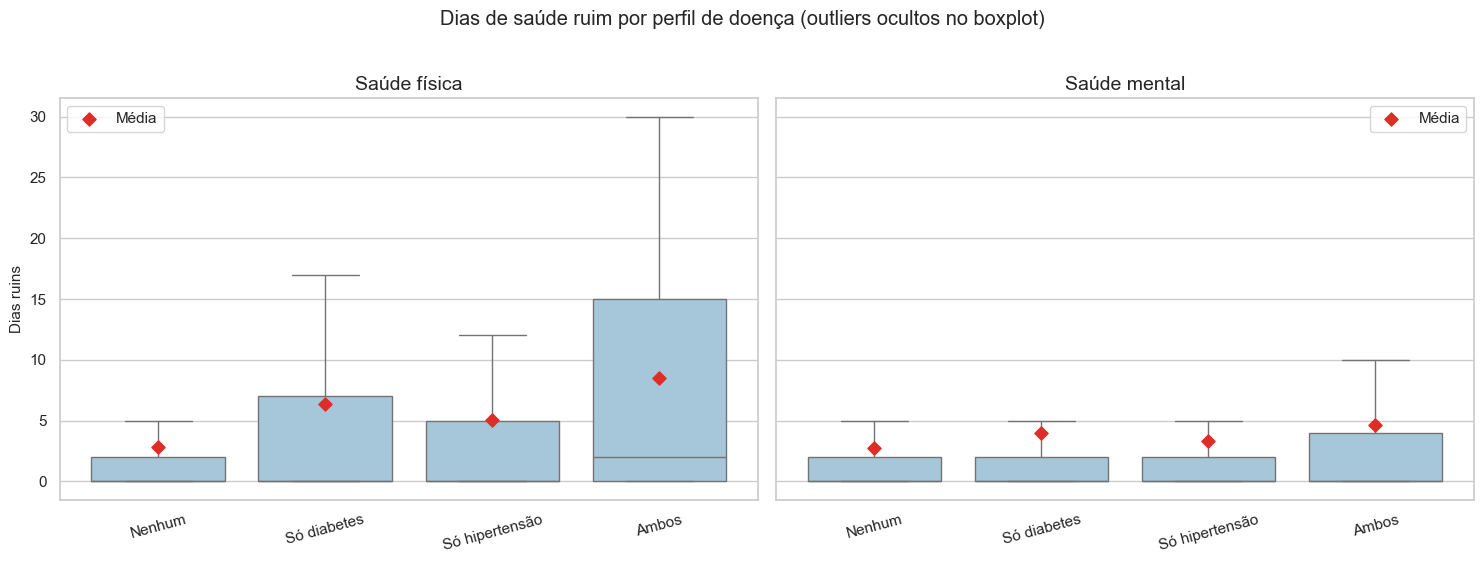

In [3]:
long_dias = df_e6.melt(
    id_vars="Perfil_doenca", value_vars=["PhysHlth", "MentHlth"],
    var_name="Indicador", value_name="Dias ruins"
)
long_dias["Indicador"] = long_dias["Indicador"].map({
    "PhysHlth": "Saúde física", "MentHlth": "Saúde mental"
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, indicador in zip(axes, ["Saúde física", "Saúde mental"]):
    dados_plot = long_dias[long_dias["Indicador"] == indicador]
    sns.boxplot(
        data=dados_plot, x="Perfil_doenca", y="Dias ruins", order=ordem_perfis,
        showfliers=False, color="#9ecae1", ax=ax
    )
    medias = dados_plot.groupby("Perfil_doenca", observed=False)["Dias ruins"].mean().reindex(ordem_perfis)
    ax.scatter(range(4), medias, color="#de2d26", marker="D", s=45, zorder=3, label="Média")
    ax.set_title(indicador)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.legend()
fig.suptitle("Dias de saúde ruim por perfil de doença (outliers ocultos no boxplot)", y=1.02)
plt.tight_layout()
plt.show()

,Indicador,H de Kruskal–Wallis,p-valor,Epsilon²
0,Saúde física,9433.046,"<0,001",0.037
1,Saúde mental,464.078,"<0,001",0.002
2,Saúde geral,35591.752,"<0,001",0.140


,1 — Excelente,2 — Muito boa,3 — Boa,4 — Regular,5 — Ruim
Perfil_doenca,,,,,
Nenhum,26.26,40.52,24.41,6.65,2.16
Só diabetes,4.68,23.75,40.19,22.64,8.75
Só hipertensão,10.24,33.50,35.23,15.48,5.55
Ambos,2.75,16.18,37.38,29.36,14.33


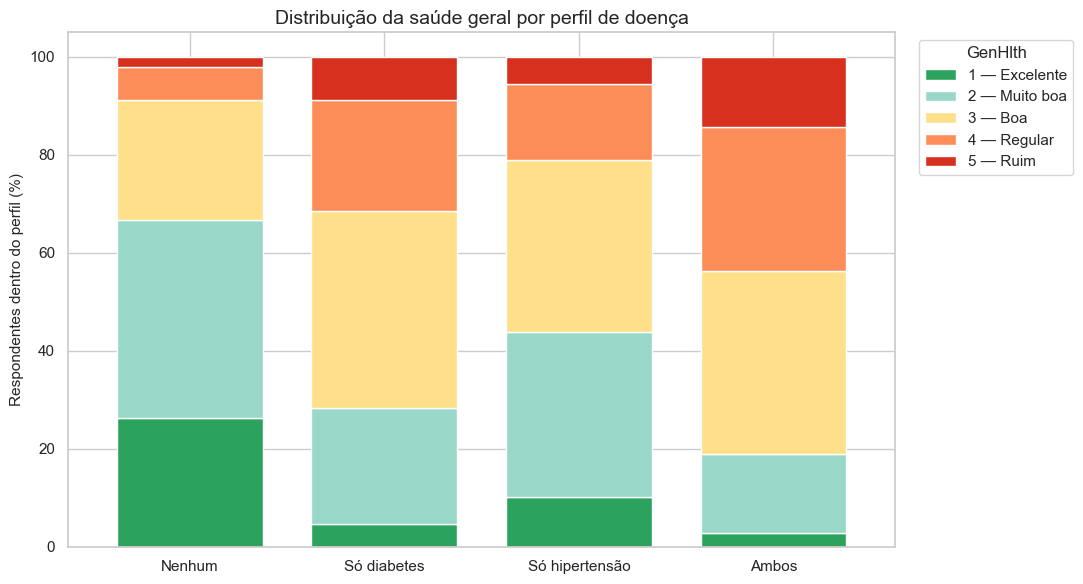

In [4]:
testes_e6 = []
for var, nome in [("PhysHlth", "Saúde física"), ("MentHlth", "Saúde mental"), ("GenHlth", "Saúde geral")]:
    amostras = [df_e6.loc[df_e6["Perfil_doenca"] == p, var] for p in ordem_perfis]
    teste = stats.kruskal(*amostras)
    n = sum(len(x) for x in amostras)
    k = len(amostras)
    epsilon2 = max(0, (teste.statistic - k + 1) / (n - k))
    testes_e6.append({
        "Indicador": nome, "H de Kruskal–Wallis": teste.statistic,
        "p-valor": teste.pvalue, "Epsilon²": epsilon2
    })
testes_e6 = pd.DataFrame(testes_e6)
testes_e6["p-valor"] = testes_e6["p-valor"].map(lambda x: "<0,001" if x < 0.001 else f"{x:.3f}")
display(testes_e6.round(3))

dist_gen = pd.crosstab(
    df_e6["Perfil_doenca"], df_e6["GenHlth"], normalize="index"
).reindex(ordem_perfis).mul(100)
dist_gen.columns = ["1 — Excelente", "2 — Muito boa", "3 — Boa", "4 — Regular", "5 — Ruim"]
display(dist_gen.round(2))

cores = ["#2ca25f", "#99d8c9", "#fee08b", "#fc8d59", "#d7301f"]
ax = dist_gen.plot(kind="bar", stacked=True, figsize=(11, 6), color=cores, width=0.75)
ax.set_title("Distribuição da saúde geral por perfil de doença")
ax.set_xlabel("")
ax.set_ylabel("Respondentes dentro do perfil (%)")
ax.set_xticklabels(ordem_perfis, rotation=0)
ax.legend(title="GenHlth", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Interpretação do Eixo 6

- O perfil **com diabetes e hipertensão simultaneamente** apresenta a maior média de dias de saúde física ruim e a maior proporção de pessoas com 14 ou mais dias físicos ruins.
- A mediana é zero em vários perfis porque muitos respondentes não relataram nenhum dia ruim. Por isso, média, mediana, proporção ≥14 dias e distribuição completa devem ser lidas em conjunto.
- As diferenças de saúde mental existem, mas são menos acentuadas do que as de saúde física e saúde geral. O tamanho de efeito (`epsilon²`) dá contexto adicional ao p-valor.
- Em `GenHlth`, a distribuição se desloca progressivamente das categorias “excelente/muito boa” para “regular/ruim”, sobretudo quando as duas doenças coexistem.
- Como idade e outros fatores diferem entre os perfis, estes resultados representam carga observada, e não efeito causal isolado de cada doença.